# 🏠 MietCheck · 💡 QUA³CK-Phase 6: Wissensextraktion (Knowledge)

**Modul:** Data Analytics & Big Data (IU, 4. Semester) · **Projekt:** MietCheck – „Zahle ich zu viel Miete?"

> Teil 6 von 6 der QUA³CK-Notebook-Serie. Reihenfolge:
> **Q**ualitätsprüfung → **U**nderstanding → **A**lgorithmenauswahl →
> Modellentwicklung → **C**ross-Validation → **K**nowledge.

**Ziel:** aus dem Modell verwertbares Wissen ziehen und es nutzbar machen – als **App für Alltagsuser** (der USP).

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import config as C
sns.set_theme(style='whitegrid', palette='rocket')
print('Setup ok ·', ROOT.name)

Setup ok · MietCheck


In [2]:
from joblib import load
model = load(C.MODEL_FILE)
m = json.loads((C.REPORT_DIR/'metrics.json').read_text())
print('Modell geladen ·', m['best_model'])

Modell geladen · Gradient Boosting


## 1. Was treibt den Preis? (Merkmalswichtigkeit)

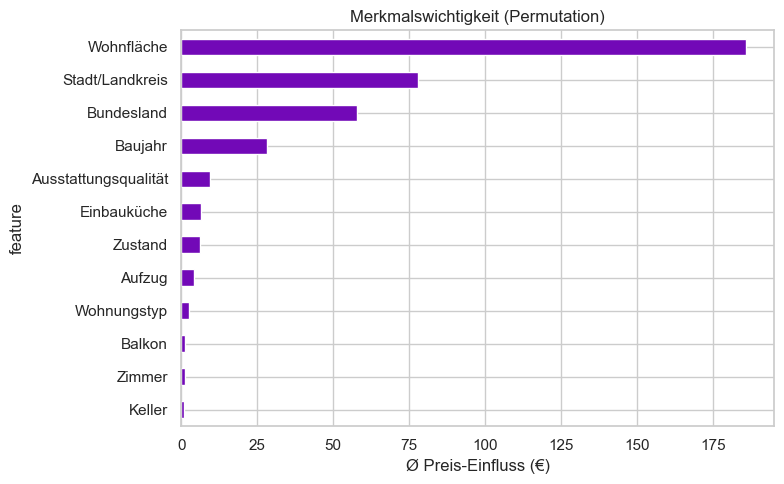

In [3]:
imp = pd.DataFrame(m['importances']).sort_values('value')
ax = imp.set_index('feature')['value'].plot.barh(figsize=(8,5), color='#7209b7')
ax.set(title='Merkmalswichtigkeit (Permutation)', xlabel='Ø Preis-Einfluss (€)')
plt.tight_layout(); plt.show()

## 2. Wie gut trifft das Modell? (Vorhersage vs. Realität)

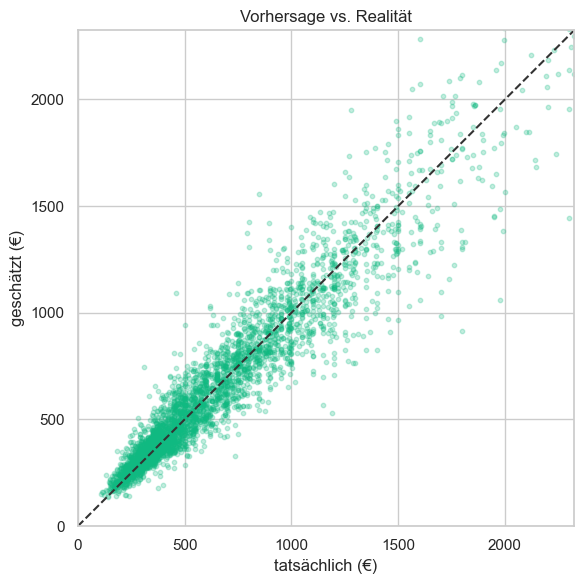

In [4]:
df = pd.read_parquet(C.CLEAN_PARQUET).sample(4000, random_state=0)
pred = model.predict(df[C.FEATURES]); real = df[C.TARGET].values
lim = np.percentile(real, 99)
plt.figure(figsize=(6,6))
plt.scatter(real, pred, alpha=0.25, s=10, color='#10b981')
plt.plot([0,lim],[0,lim],'--',color='#333')
plt.xlim(0,lim); plt.ylim(0,lim)
plt.xlabel('tatsächlich (€)'); plt.ylabel('geschätzt (€)')
plt.title('Vorhersage vs. Realität'); plt.tight_layout(); plt.show()

## 3. Anwendung: eine Beispiel-Abfrage

In [5]:
def schaetze(flaeche, zimmer, bundesland, stadt, baujahr=1990, zustand='well_kept'):
    row = pd.DataFrame([{ 'livingSpace':flaeche,'noRooms':zimmer,'yearConstructed':baujahr,
      'regio1':bundesland,'regio2':stadt,'condition':zustand,'interiorQual':'normal',
      'typeOfFlat':'apartment','balcony':True,'hasKitchen':True,'cellar':False,
      'lift':False,'garden':False,'newlyConst':False }])
    return model.predict(row)[0]
for stadt in [('Berlin','Berlin'),('Bayern','München'),('Sachsen','Leipzig')]:
    p = schaetze(70,2.0,stadt[0],stadt[1])
    print(f'  70 m², {stadt[1]:10}: {p:6.0f} € ({p/70:.2f} €/m²)')

  70 m², Berlin    :    694 € (9.91 €/m²)
  70 m², München   :   1257 € (17.96 €/m²)
  70 m², Leipzig   :    444 € (6.34 €/m²)


## 4. Vom Modell zur App (Deployment)
Das Wissen wird als **Streamlit-App** ausgeliefert – der eigentliche USP:

```bash
streamlit run app.py
```

5 Seiten: 🏠 Check · 🗺️ Markt (Deutschland-Karte) · 🧮 Budget · 📈 Modell · ℹ️ Über.

## ✅ Fazit Phase K & Gesamtprojekt
- Wichtigste Preistreiber: **Wohnfläche, Stadt, Bundesland**.
- Das Modell schätzt die faire Kaltmiete mit **± ~90 € (R² ≈ 0,90)**.
- Ausgeliefert als interaktive App → beantwortet die Alltagsfrage *„Zahle ich zu viel Miete?“*.

**Damit ist der QUA³CK-Zyklus vollständig durchlaufen.** 🎉